## Avaliação no conjunto de teste externo (holdout)

Este notebook avalia o modelo treinado no notebook 04 usando o conjunto de holdout (dataset_teste_externo/) — imagens nunca vistas em nenhuma etapa anterior (nem treino, nem validação). É o teste mais honesto possível do desempenho do modelo, simulando o teste 5 do PROJETO_CROCHE_IA.md ("peças extras nunca vistas").

Assim como nos notebooks anteriores, os resultados aqui (acurácia, matriz de confusão) não significam nada real sobre reconhecimento de crochê — servem apenas para validar que o código de avaliação funciona corretamente.

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


## Dataset customizado (importado do módulo compartilhado)

In [2]:
import sys
sys.path.append("../scripts")
from dataset import CrochetDataset

## Carregar o modelo treinado e o dataset de holdout

In [3]:
MEAN_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]

# ---------- Recriar a arquitetura do modelo ----------
# torch.save(state_dict) salva SOMENTE os pesos, nao a arquitetura --
# por isso precisamos recriar exatamente a mesma estrutura (ResNet18
# com a camada final trocada para 2 classes) antes de carregar os pesos.
modelo = models.resnet18(weights=None)  # weights=None: nao baixa pesos do
                                          # ImageNet de novo, ja que vamos
                                          # sobrescrever com os nossos
num_classes = 2
modelo.fc = nn.Linear(modelo.fc.in_features, num_classes)

caminho_modelo = "../modelos/modelo_mock_resnet18.pt"
modelo.load_state_dict(torch.load(caminho_modelo, map_location=device))
modelo = modelo.to(device)

# model.eval(): essencial para avaliacao -- desativa comportamentos de
# treino (ex: estatisticas de BatchNorm passam a usar os valores
# acumulados durante o treino, nao os do batch atual).
modelo.eval()

print("Modelo carregado e pronto para avaliação.")

# ---------- Transform do holdout (igual ao de validação: sem augmentation) ----------
transform_holdout = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=MEAN_IMAGENET, std=STD_IMAGENET),
    ToTensorV2(),
])

# ---------- Dataset e DataLoader do holdout ----------
dataset_holdout = CrochetDataset(
    caminho_csv="../dataset_teste_externo/labels_mock_holdout.csv",
    pasta_imagens="../dataset_teste_externo",
    transform=transform_holdout,
)

dataloader_holdout = DataLoader(dataset_holdout, batch_size=8, shuffle=False)

print(f"Imagens no holdout: {len(dataset_holdout)}")

Modelo carregado e pronto para avaliação.
Imagens no holdout: 26


## Previsões no holdout e matriz de confusão

In [4]:
# Listas para acumular rotulos verdadeiros e previstos de todo o holdout,
# usadas em seguida para calcular a matriz de confusao e o relatorio.
rotulos_verdadeiros = []
rotulos_previstos = []

with torch.no_grad():
    for imagens, rotulos in dataloader_holdout:
        imagens = imagens.to(device)
        rotulos = rotulos.to(device)

        saidas = modelo(imagens)
        _, previsoes = torch.max(saidas, 1)

        rotulos_verdadeiros.extend(rotulos.cpu().numpy())
        rotulos_previstos.extend(previsoes.cpu().numpy())

print(f"Total de previsões geradas: {len(rotulos_previstos)}")

Total de previsões geradas: 26


## Matriz de confusão e relatório de métricas

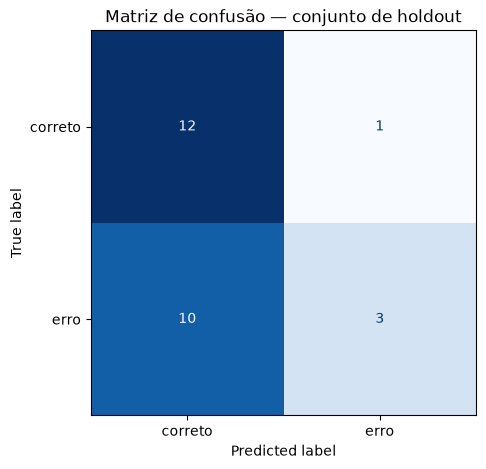

              precision    recall  f1-score   support

     correto       0.55      0.92      0.69        13
        erro       0.75      0.23      0.35        13

    accuracy                           0.58        26
   macro avg       0.65      0.58      0.52        26
weighted avg       0.65      0.58      0.52        26



In [5]:
nomes_classes = ["correto", "erro"]

# Matriz de confusao: linhas = classe verdadeira, colunas = classe
# prevista. A diagonal principal mostra os acertos; fora da diagonal,
# os erros do modelo (e em qual direcao ele errou).
matriz = confusion_matrix(rotulos_verdadeiros, rotulos_previstos)

fig, ax = plt.subplots(figsize=(6, 5))
display = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
display.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão — conjunto de holdout")
plt.show()

# classification_report: gera precisao, recall e f1-score por classe --
# metricas mais informativas que so "acuracia" quando as classes podem
# ter comportamentos diferentes (ex: o modelo pode ser bom em detectar
# "correto" mas ruim em detectar "erro", ou vice-versa).
print(classification_report(rotulos_verdadeiros, rotulos_previstos, target_names=nomes_classes))